# How to use RL to solve any problem?

## 1. Install & Import Dependencies

In [30]:
# Install required packages (run once)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'gymnasium', 'numpy', 'matplotlib', 'seaborn'], check=True)

CompletedProcess(args=['/home/balbir/ba/sem-II/PIML/codes/pimlEnv/bin/python', '-m', 'pip', 'install', 'gymnasium', 'numpy', 'matplotlib', 'seaborn'], returncode=0)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces
from IPython.display import HTML
from collections import deque, namedtuple
import warnings
import random
import csv

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import trange


# Reproducibility
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass


warnings.filterwarnings('ignore')

print('✅ All imports successful!')
print(f'   Gymnasium version: {gym.__version__}')

✅ All imports successful!
   Gymnasium version: 1.2.3


## Discrete Space and Discrete Action : Maze Environment

In [32]:
class MazeEnv(gym.Env):
    """
    Custom Gymnasium Maze Environment.

    Grid legend:
      0 = free cell
      1 = wall
      2 = start
      3 = goal

    Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    """
    metadata = {'render_modes': ['human', 'rgb_array']}

    # ── Default 10×10 maze (0=free, 1=wall) ──────────────────────────────────
    DEFAULT_MAZE = np.array([
        [2, 0, 1, 0, 0, 0, 1, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
        [1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
        [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 0, 3],
    ], dtype=np.int32)

    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}  # dr, dc
    ACTION_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    def __init__(self, maze=None, max_steps=500, render_mode=None):
        super().__init__()
        self.maze = (maze if maze is not None else self.DEFAULT_MAZE).copy()
        self.nrows, self.ncols = self.maze.shape
        self.max_steps = max_steps
        self.render_mode = render_mode

        # Locate start & goal
        self.start_pos = tuple(map(int, np.argwhere(self.maze == 2)[0]))
        self.goal_pos  = tuple(map(int, np.argwhere(self.maze == 3)[0]))

        n_states = self.nrows * self.ncols
        self.observation_space = spaces.Discrete(n_states)
        self.action_space      = spaces.Discrete(4)

        self._state = None
        self._steps = 0

    # ── helpers ──────────────────────────────────────────────────────────────
    def _pos_to_state(self, r, c):  return r * self.ncols + c
    def _state_to_pos(self, s):     return divmod(s, self.ncols)
    def _is_free(self, r, c):
        return 0 <= r < self.nrows and 0 <= c < self.ncols and self.maze[r, c] != 1

    # ── Gymnasium API ─────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._state = self._pos_to_state(*self.start_pos)
        self._steps = 0
        return self._state, {}

    def step(self, action):
        r, c = self._state_to_pos(self._state)
        dr, dc = self.ACTIONS[action]
        nr, nc = r + dr, c + dc

        if self._is_free(nr, nc):
            r, c = nr, nc

        self._state = self._pos_to_state(r, c)
        self._steps += 1

        reached_goal = (r, c) == self.goal_pos
        truncated    = self._steps >= self.max_steps

        if reached_goal:
            reward = 100.0
        else:
            # Small step penalty encourages shorter paths
            reward = -1.0

        return self._state, reward, reached_goal, truncated, {}

    def get_current_pos(self):
        return self._state_to_pos(self._state)


print('✅ MazeEnv defined')

✅ MazeEnv defined


## Visualize the Initial Maze

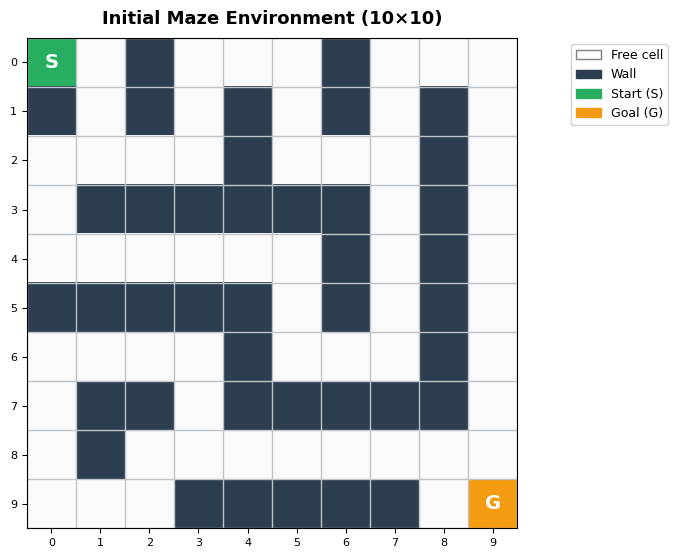

Maze shape : (10, 10)
Start pos  : (0, 0)
Goal pos   : (9, 9)
State space: 100
Action space: 4  (0=↑ 1=↓ 2=← 3=→)


In [33]:
def draw_maze(maze, ax=None, title='Maze', show_grid=True):
    """Render the maze grid with color-coded cells."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    # Color map: free=white, wall=dark, start=green, goal=gold
    cmap = ListedColormap(['#FAFAFA', '#2C3E50', '#27AE60', '#F39C12'])

    ax.imshow(maze, cmap=cmap, vmin=0, vmax=3, origin='upper')

    nrows, ncols = maze.shape
    if show_grid:
        ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
        ax.grid(which='minor', color='#BDC3C7', linewidth=1)
        ax.tick_params(which='minor', length=0)

    ax.set_xticks(range(ncols))
    ax.set_yticks(range(nrows))
    ax.set_xticklabels(range(ncols), fontsize=8)
    ax.set_yticklabels(range(nrows), fontsize=8)

    # Annotate start / goal
    sr, sc = map(int, np.argwhere(maze == 2)[0])
    gr, gc = map(int, np.argwhere(maze == 3)[0])
    ax.text(sc, sr, 'S', ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')
    ax.text(gc, gr, 'G', ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')

    # Legend
    legend_patches = [
        mpatches.Patch(color='#FAFAFA', label='Free cell', ec='gray'),
        mpatches.Patch(color='#2C3E50', label='Wall'),
        mpatches.Patch(color='#27AE60', label='Start (S)'),
        mpatches.Patch(color='#F39C12', label='Goal (G)'),
    ]
    ax.legend(handles=legend_patches, loc='upper right',
              bbox_to_anchor=(1.32, 1), fontsize=9, framealpha=0.9)

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    return ax


env = MazeEnv()
fig, ax = plt.subplots(figsize=(7, 7))
draw_maze(env.maze, ax=ax, title='Initial Maze Environment (10×10)')
plt.tight_layout()
plt.savefig('/tmp/maze_initial.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Maze shape : {env.maze.shape}')
print(f'Start pos  : {env.start_pos}')
print(f'Goal pos   : {env.goal_pos}')
print(f'State space: {env.observation_space.n}')
print(f'Action space: {env.action_space.n}  (0=↑ 1=↓ 2=← 3=→)')

## Q-Learning Algorithm

---

### 🧠 What is Q-Learning?

**Q-Learning** is a *model-free*, *off-policy* reinforcement learning algorithm. The agent learns the value of taking a given action from a given state — without needing to know anything about the maze layout in advance. It discovers the optimal path purely through trial, error, and reward feedback.

---

### 🗺️ Mapping the Maze to an RL Problem

| RL Concept | Maze Equivalent |
|---|---|
| **State** `s` | Agent's current cell `(row, col)` → flattened to integer index |
| **Action** `a` | Move: `↑ ↓ ← →` (4 choices) |
| **Reward** `r` | `+100` on reaching the Goal; `−1` per step (encourages shorter paths) |
| **Episode** | One attempt from **S** until **G** is reached or `max_steps` exceeded |
| **Policy** `π` | The agent's rule for choosing an action in each cell |

---

### 📊 The Q-Table

The core data structure is the **Q-table** — a 2-D matrix of shape `(n_states × n_actions)`:

```
         ↑       ↓       ←       →
cell 0 [ 0.00   0.00   0.00   0.00 ]
cell 1 [ 0.00   0.00   0.00   0.00 ]
  ...          (initialized to zeros)
cell 99[ 0.00   0.00   0.00   0.00 ]
```

`Q[s, a]` estimates the **total discounted future reward** the agent can expect if it takes action `a` from state `s` and then follows the optimal policy thereafter.

---

### ⚙️ The Bellman Update (Core Rule)

After every step `(s, a, r, s')`, the Q-table is updated with:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \Big]$$

| Symbol | Name | Role in this notebook |
|---|---|---|
| `α` (alpha) | **Learning rate** | `0.1` — how much each new experience overwrites old estimates |
| `γ` (gamma) | **Discount factor** | `0.99` — how much future rewards matter vs. immediate ones |
| `r` | **Reward** | `−1` per step, `+100` at goal |
| `max Q(s', a')` | **Bootstrap target** | Best known Q-value reachable from the next state |
| `TD error` | **`r + γ·maxQ − Q(s,a)`** | The "surprise" signal — drives learning |

**Intuition:** If the agent stumbles onto a good next state, the TD error is positive → Q goes up for that `(state, action)` pair. If the next state turns out worse than expected, TD error is negative → Q goes down. Over thousands of episodes, these nudges propagate backwards from the goal, carving a gradient of increasing Q-values that points toward the exit.

---

### 🎲 Exploration vs. Exploitation — ε-Greedy Policy

The agent faces a dilemma every step:

- **Exploit** — go to the cell with the highest Q-value (use what it already knows)
- **Explore** — try a random direction (discover potentially better routes)

This is resolved with an **ε-greedy** strategy:

```
With probability  ε  → choose a RANDOM action   (explore)
With probability 1-ε → choose argmax_a Q(s, a)  (exploit)
```

ε starts at **1.0** (fully random) and decays by a factor of `0.997` each episode, converging toward **0.01**. Early episodes explore the whole maze freely; later episodes greedily exploit the accumulated knowledge.

```
Episode 1    ε = 1.000  ████████████████████  100% random
Episode 500  ε ≈ 0.220  ████░░░░░░░░░░░░░░░░   22% random
Episode 1000 ε ≈ 0.050  █░░░░░░░░░░░░░░░░░░░    5% random
Episode 2000 ε = 0.010  ░░░░░░░░░░░░░░░░░░░░    1% random
```

---

### 🔄 Full Episode Loop

```
Initialize Q(s, a) = 0  for all s, a

For each episode:
  │
  ├─ Reset env → agent placed at START cell S
  │
  └─ For each step t:
       │
       ├─ 1. OBSERVE  current state s  (cell index)
       │
       ├─ 2. SELECT   action a  via ε-greedy on Q[s]
       │
       ├─ 3. EXECUTE  action → env returns (s', r, done)
       │              • hit wall? stay in s
       │              • free cell? move to s'
       │              • goal cell? r = +100, done = True
       │
       ├─ 4. UPDATE   Q(s, a) += α · [r + γ · max Q(s',·) − Q(s, a)]
       │
       ├─ 5. ADVANCE  s ← s'
       │
       └─ 6. BREAK if done
  │
  └─ Decay ε  (reduce exploration)

Extract greedy policy:  π(s) = argmax_a Q(s, a)
```



In [34]:
class QLearningAgent:
    """Tabular Q-Learning with ε-greedy exploration."""

    def __init__(self, n_states, n_actions,
                 alpha=0.1, gamma=0.99,
                 eps_start=1.0, eps_end=0.01, eps_decay=0.995):
        self.n_states  = n_states
        self.n_actions = n_actions
        self.alpha     = alpha      # learning rate
        self.gamma     = gamma      # discount factor
        self.epsilon   = eps_start
        self.eps_end   = eps_end
        self.eps_decay = eps_decay

        self.Q = np.zeros((n_states, n_actions))

    def choose_action(self, state):
        """ε-greedy action selection."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)  # explore
        return int(np.argmax(self.Q[state]))           # exploit

    def update(self, s, a, r, s_next, done):
        """Bellman update."""
        target = r + (0 if done else self.gamma * np.max(self.Q[s_next]))
        self.Q[s, a] += self.alpha * (target - self.Q[s, a])

    def decay_epsilon(self):
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)

    def greedy_policy(self):
        """Return the greedy action for every state."""
        return np.argmax(self.Q, axis=1)


print('✅ QLearningAgent defined')

✅ QLearningAgent defined


## Train the Agent

In [35]:
# ── Hyper-parameters ─────────────────────────────────────────────────────────
N_EPISODES   = 2500
MAX_STEPS    = 500
ALPHA        = 0.1
GAMMA        = 0.99
EPS_START    = 1.0
EPS_END      = 0.01
EPS_DECAY    = 0.997
LOG_EVERY    = 500

# ── Setup ─────────────────────────────────────────────────────────────────────
env   = MazeEnv(max_steps=MAX_STEPS)
agent = QLearningAgent(
    n_states  = env.observation_space.n,
    n_actions = env.action_space.n,
    alpha     = ALPHA, gamma = GAMMA,
    eps_start = EPS_START, eps_end = EPS_END, eps_decay = EPS_DECAY
)

# ── Training loop ─────────────────────────────────────────────────────────────
rewards_log  = []
steps_log    = []
success_log  = []
epsilon_log  = []

print(f'Training Q-Learning agent for {N_EPISODES} episodes …')
print(f'{"Episode":>10}  {"Avg Reward":>12}  {"Avg Steps":>10}  '
      f'{"Success%":>10}  {"Epsilon":>8}')
print('─' * 60)

for ep in range(1, N_EPISODES + 1):
    state, _ = env.reset()
    ep_reward = 0.0

    for step in range(MAX_STEPS):
        action = agent.choose_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.update(state, action, reward, next_state, done)
        state      = next_state
        ep_reward += reward

        if done:
            break

    agent.decay_epsilon()
    rewards_log.append(ep_reward)
    steps_log.append(step + 1)
    success_log.append(int(terminated))   # terminated = reached goal
    epsilon_log.append(agent.epsilon)

    if ep % LOG_EVERY == 0:
        window = slice(-LOG_EVERY, None)
        print(f'{ep:>10}  '
              f'{np.mean(rewards_log[window]):>12.2f}  '
              f'{np.mean(steps_log[window]):>10.1f}  '
              f'{100*np.mean(success_log[window]):>9.1f}%  '
              f'{agent.epsilon:>8.4f}')

print('\n✅ Training complete!')

Training Q-Learning agent for 2500 episodes …
   Episode    Avg Reward   Avg Steps    Success%   Epsilon
────────────────────────────────────────────────────────────
       500         -5.70       100.0       93.4%    0.2226
      1000         71.18        29.8      100.0%    0.0496
      1500         74.24        26.8      100.0%    0.0110
      2000         74.78        26.2      100.0%    0.0100
      2500         74.73        26.3      100.0%    0.0100

✅ Training complete!


## Training Curves

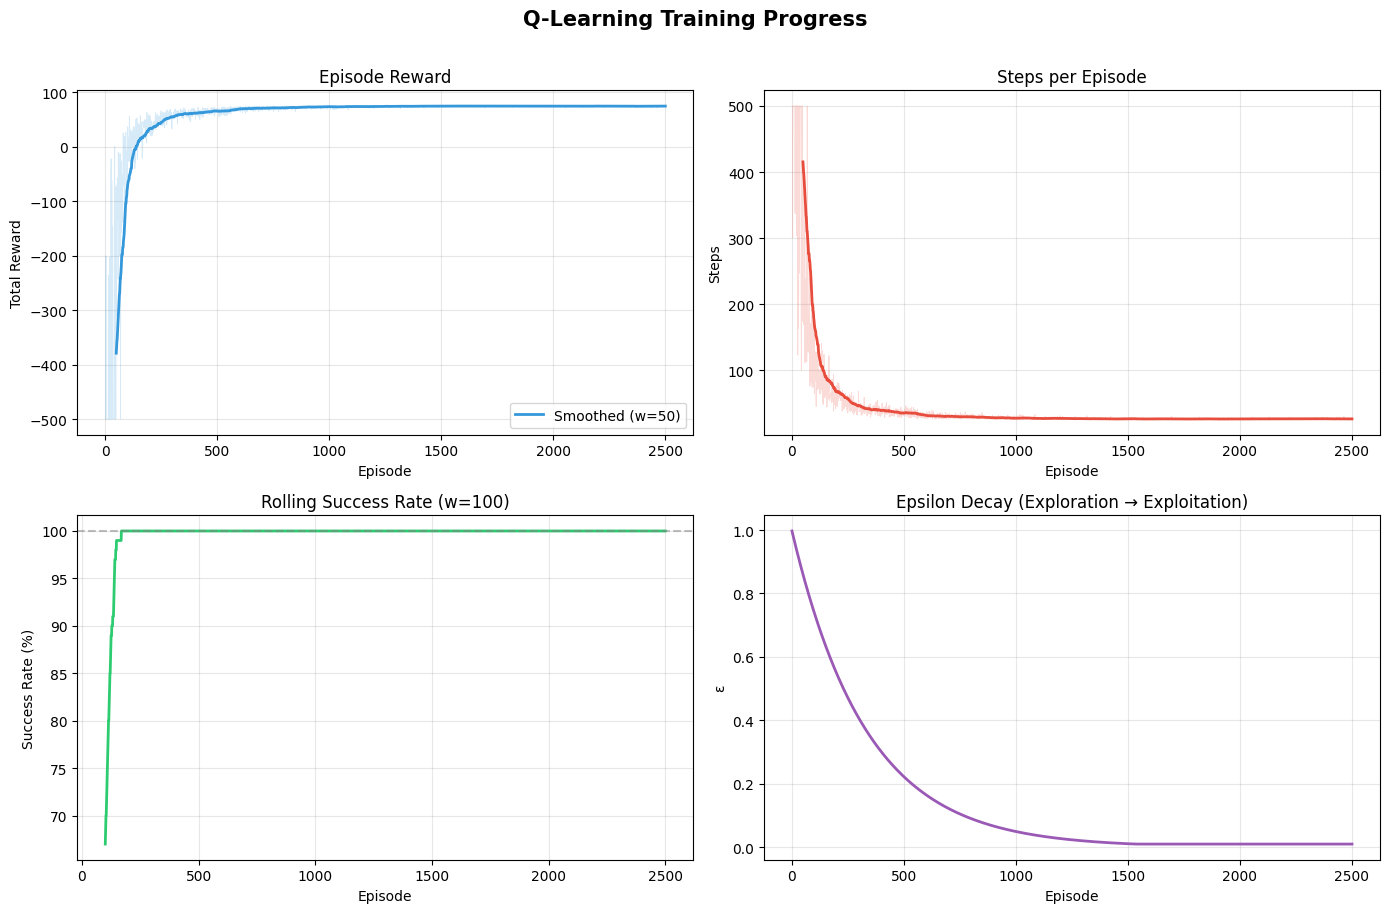

In [36]:
def smooth(arr, w=50):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Q-Learning Training Progress', fontsize=15, fontweight='bold', y=1.01)

palette = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6']
eps = range(1, N_EPISODES + 1)

# (a) Episode reward
ax = axes[0, 0]
ax.plot(eps, rewards_log, alpha=0.2, color=palette[0], linewidth=0.6)
ax.plot(range(50, N_EPISODES + 1), smooth(rewards_log), color=palette[0], linewidth=2, label='Smoothed (w=50)')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.set_title('Episode Reward'); ax.legend(); ax.grid(alpha=0.3)

# (b) Steps per episode
ax = axes[0, 1]
ax.plot(eps, steps_log, alpha=0.2, color=palette[1], linewidth=0.6)
ax.plot(range(50, N_EPISODES + 1), smooth(steps_log), color=palette[1], linewidth=2)
ax.set_xlabel('Episode'); ax.set_ylabel('Steps')
ax.set_title('Steps per Episode'); ax.grid(alpha=0.3)

# (c) Rolling success rate
ax = axes[1, 0]
roll_success = smooth(success_log, w=100) * 100
ax.plot(range(100, N_EPISODES + 1), roll_success, color=palette[2], linewidth=2)
ax.axhline(100, ls='--', color='gray', alpha=0.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Success Rate (%)')
ax.set_title('Rolling Success Rate (w=100)'); ax.grid(alpha=0.3)

# (d) Epsilon decay
ax = axes[1, 1]
ax.plot(eps, epsilon_log, color=palette[3], linewidth=2)
ax.set_xlabel('Episode'); ax.set_ylabel('ε')
ax.set_title('Epsilon Decay (Exploration → Exploitation)'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Animate the Agent's Optimal Path

In [ ]:
# ── Ensure we are using a Maze environment in this cell ───────────────────────
if hasattr(env, 'get_current_pos') and hasattr(env, 'maze'):
    env_maze_anim = env
else:
    if 'env_maze' in globals() and hasattr(env_maze, 'get_current_pos'):
        env_maze_anim = env_maze
    else:
        env_maze_anim = MazeEnv(max_steps=MAX_STEPS if 'MAX_STEPS' in globals() else 500)

# ── Helper: collect greedy path ───────────────────────────────────────────────
def get_greedy_path(env_obj, agent):
    state, _ = env_obj.reset()
    path    = [env_obj.get_current_pos()]
    actions = []
    for _ in range(env_obj.max_steps):
        action = int(np.argmax(agent.Q[state]))
        actions.append(action)
        state, _, terminated, truncated, _ = env_obj.step(action)
        path.append(env_obj.get_current_pos())
        if terminated or truncated:
            break
    return path, actions

path, path_actions = get_greedy_path(env_maze_anim, agent)
print(f'Greedy path length : {len(path)-1} steps')
print(f'Reached goal       : {path[-1] == env_maze_anim.goal_pos}')

# ── Pre-compute V(s) heatmap data ─────────────────────────────────────────────
V        = np.max(agent.Q, axis=1).reshape(env_maze_anim.nrows, env_maze_anim.ncols)
wall_mask = env_maze_anim.maze == 1
V_display = np.where(wall_mask, np.nan, V)          # NaN → drawn as wall colour
cmap_v    = plt.cm.RdYlGn.copy()
cmap_v.set_bad(color='#2C3E50')

policy     = agent.greedy_policy()
ACTION_LABELS = ['↑ Up', '↓ Down', '← Left', '→ Right']
BAR_COLORS    = ['#3498DB', '#3498DB', '#3498DB', '#3498DB']   # default blue
CHOSEN_COLOR  = '#F39C12'                                       # gold for chosen

# Arrow delta map: (dx_col, dy_row)  — matplotlib axes convention
ARROW_MAP = {0: (0, -0.32), 1: (0, 0.32), 2: (-0.32, 0), 3: (0.32, 0)}

# ── Build figure ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 7))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.1, 0.9], wspace=0.22)
ax_maze = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])
fig.patch.set_facecolor('#F8F9FA')

# ── LEFT PANEL — static background ───────────────────────────────────────────
im = ax_maze.imshow(V_display, cmap=cmap_v, origin='upper',
                    interpolation='nearest', alpha=0.85,
                    vmin=np.nanmin(V_display), vmax=np.nanmax(V_display))
plt.colorbar(im, ax=ax_maze, fraction=0.038, pad=0.06,
             label='V(s) = max Q(s,·)', shrink=0.92)

# Minor grid
ax_maze.set_xticks(np.arange(-0.5, env_maze_anim.ncols, 1), minor=True)
ax_maze.set_yticks(np.arange(-0.5, env_maze_anim.nrows, 1), minor=True)
ax_maze.grid(which='minor', color='#95A5A6', linewidth=0.6)
ax_maze.tick_params(which='minor', length=0)

# Static policy arrows (all cells)
for r in range(env_maze_anim.nrows):
    for c in range(env_maze_anim.ncols):
        if env_maze_anim.maze[r, c] == 1 or (r, c) == env_maze_anim.goal_pos:
            continue
        s  = env_maze_anim._pos_to_state(r, c)
        dx, dy = ARROW_MAP[policy[s]]
        ax_maze.annotate('', xy=(c + dx, r + dy), xytext=(c, r),
                         arrowprops=dict(arrowstyle='->', color='#2C3E50',
                                         lw=1.3, mutation_scale=11),
                         zorder=3)

# S / G labels
sr, sc = env_maze_anim.start_pos
gr, gc = env_maze_anim.goal_pos
ax_maze.text(sc, sr, 'S', ha='center', va='center', fontsize=11,
             fontweight='bold', color='white', zorder=6)
ax_maze.text(gc, gr, 'G', ha='center', va='center', fontsize=11,
             fontweight='bold', color='white', zorder=6)

# Ghost trail (full path, faint)
ax_maze.plot([p[1] for p in path], [p[0] for p in path],
             '-', color='#E74C3C', linewidth=1.2, alpha=0.18, zorder=2)

# ── Dynamic elements on left panel ───────────────────────────────────────────
active_trail, = ax_maze.plot([], [], '-', color='#E74C3C',
                              linewidth=2.2, alpha=0.85, zorder=4)
agent_dot,    = ax_maze.plot([], [], 'o', color='#E74C3C', markersize=16,
                              zorder=7, markeredgecolor='white', markeredgewidth=2)

# Highlight ring around current cell
cell_highlight = plt.Rectangle((-0.5, -0.5), 1, 1,
                                linewidth=2.5, edgecolor='white',
                                facecolor='white', alpha=0.35, zorder=5)
ax_maze.add_patch(cell_highlight)

info_text = ax_maze.text(
    0.02, 0.985, '', transform=ax_maze.transAxes,
    fontsize=9.5, va='top', family='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor='#BDC3C7', alpha=0.92))

ax_maze.set_title('V(s) Heatmap  ·  Greedy Policy Arrows  ·  Agent Path',
                   fontsize=11, fontweight='bold', pad=10)

# ── RIGHT PANEL — Q-value bar chart ──────────────────────────────────────────
ax_bar.set_facecolor('#F8F9FA')
init_state = env_maze_anim._pos_to_state(*path[0])
q_vals     = agent.Q[init_state]
bars       = ax_bar.barh(ACTION_LABELS, q_vals, color=BAR_COLORS,
                          edgecolor='white', height=0.55)
ax_bar.axvline(0, color='#7F8C8D', linewidth=0.8, linestyle='--')
ax_bar.set_xlabel('Q-value', fontsize=10)
ax_bar.set_title('Q(s, a)  for Current Cell', fontsize=11,
                  fontweight='bold', pad=10)
ax_bar.spines[['top', 'right']].set_visible(False)
ax_bar.tick_params(axis='y', labelsize=12)

# Value labels on bars
bar_labels = [ax_bar.text(0, i, '', va='center', ha='left',
                            fontsize=9, color='#2C3E50')
               for i in range(4)]

# ── Animation functions ───────────────────────────────────────────────────────
def init_anim():
    active_trail.set_data([], [])
    agent_dot.set_data([], [])
    cell_highlight.set_xy((-10, -10))   # hide off-screen
    info_text.set_text('')
    for bar in bars:
        bar.set_width(0)
    return (active_trail, agent_dot, cell_highlight,
            info_text, *bars, *bar_labels)


def update_anim(frame):
    r, c   = path[frame]
    state  = env_maze_anim._pos_to_state(r, c)
    q_vals = agent.Q[state]
    chosen = path_actions[frame] if frame < len(path_actions) else int(np.argmax(q_vals))

    # ── left panel ──
    active_trail.set_data([p[1] for p in path[:frame+1]],
                           [p[0] for p in path[:frame+1]])
    agent_dot.set_data([c], [r])
    cell_highlight.set_xy((c - 0.5, r - 0.5))

    info_text.set_text(
        f'Step : {frame:>3d} / {len(path)-1}\n'
        f'Cell : ({r}, {c})\n'
        f'State: {state:>3d}\n'
        f'V(s) : {np.max(q_vals):>6.1f}'
    )

    # ── right panel ──
    q_min = min(q_vals.min(), 0)
    q_max = max(q_vals.max(), 1)
    ax_bar.set_xlim(q_min * 1.15, q_max * 1.15)

    for i, (bar, lbl) in enumerate(zip(bars, bar_labels)):
        bar.set_width(q_vals[i])
        bar.set_color(CHOSEN_COLOR if i == chosen else '#3498DB')
        bar.set_alpha(1.0 if i == chosen else 0.65)
        offset = (q_max - q_min) * 0.03
        lbl.set_position((q_vals[i] + offset, i))
        lbl.set_text(f'{q_vals[i]:.1f}')
        lbl.set_color('#E67E22' if i == chosen else '#555555')
        lbl.set_fontweight('bold' if i == chosen else 'normal')

    return (active_trail, agent_dot, cell_highlight,
            info_text, *bars, *bar_labels)


ani = animation.FuncAnimation(
    fig, update_anim, frames=len(path),
    init_func=init_anim, interval=220, blit=True, repeat=True
)

fig.tight_layout()
plt.close(fig)
HTML(ani.to_jshtml())

AttributeError: 'TimeLimit' object has no attribute 'get_current_pos'

### DQN (Deep Q-Network) Algorithm

In [38]:
def running_average(x, N):
    ''' Function used to compute the running average
        of the last N elements of a vector x
    '''
    if len(x) >= N:
        y = np.copy(x)
        y[N-1:] = np.convolve(x, np.ones((N, )) / N, mode='valid')
    else:
        y = np.zeros_like(x)
    return y

def epsilon_decay(episode, Z, eps_max=0.99, eps_min=0.05, method="linear"):
    if method == 'linear':
        eps = eps_max - ((eps_max - eps_min) * (episode - 1)) / max(1, Z - 1)
        return max(eps_min, eps)
    if method == "exp":
        eps = eps_max * ((eps_min / eps_max) ** ((episode - 1) / max(1, Z - 1)))
        return max(eps_min, eps)

In [39]:
Experience = namedtuple('Experience',
                        ['state', 'action', 'reward', 'next_state', 'done'])

class ExperienceReplayBuffer:
    """ Class used to store a buffer containing experiences of the RL agent. """
    def __init__(self, maximum_length):
        self.buffer = deque(maxlen=maximum_length)

    def append(self, experience):
        self.buffer.append(experience)

    def __len__(self):
        return len(self.buffer)

    def sample_batch(self, n):
        """ Sample experiences from the buffer. """
        if n > len(self.buffer):
            raise IndexError('Tried to sample too many elements from the buffer!')
        
        batch = random.sample(self.buffer, n)
        return zip(*batch)

### Neural Network ###
class Agent(nn.Module):
    """ Feedforward neural network for DQN """
    def __init__(self, input_size, output_size, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.net(x)

class RandomAgent:
    ''' Agent taking actions uniformly at random '''
    def __init__(self, n_actions: int):
        self.n_actions = n_actions

    def forward(self, state: np.ndarray) -> int:
        return random.randint(0, self.n_actions - 1)


In [40]:
### CREATE RL ENVIRONMENT ###
env = gym.make('LunarLander-v3')
env.reset(seed=SEED)
env.action_space.seed(SEED)
env.observation_space.seed(SEED)

# Parameters
N_episodes = 620  # Number of episodes
discount_factor = 1.0  # Value of the discount factor
n_ep_running_average = 50  # Running average of 50 episodes
n_actions = int(env.action_space.n)  # Number of available actions
dim_state = env.observation_space.shape[0]  # State dimensionality
L = 29025  # Size of the Buffer
N = 38  # Size of batch
C = int(L / N)  # Frequency of updates
# We will use these variables to compute the average episodic reward and
# the average number of steps per episode

hidden_size = 124
method = "linear"
lr = 0.00006
max_norm = 1.846938775510204

In [41]:

import os

episode_reward_list = []  # this list contains the total reward per episode
episode_number_of_steps = []  # this list contains the number of steps per episode

### Create Experience replay buffer ###
buffer = ExperienceReplayBuffer(maximum_length=L)

best_model = Agent(input_size=dim_state, output_size=n_actions, hidden_size=hidden_size)
if os.path.exists("best_model.pth"):
    best_model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
    print("Loaded existing best_model.pth; will overwrite only when performance improves.")
else:
    torch.save(best_model.state_dict(), "best_model.pth")
    print("Initialized new best_model.pth")

### Filling up Buffer with Random experiences
agent = RandomAgent(n_actions)

for i in range(N):
    # Reset enviroment data and initialize variables
    done = False
    state, _ = env.reset(seed=SEED + i)

    while not done:
        # Take a random action
        action = agent.forward(state)

        # Get next state and reward.  The done variable
        # will be True if you reached the goal position,
        # False otherwise
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        exp = Experience(state, action, reward, next_state, done)

        buffer.append(exp)

        # Update state for next iteration
        state = next_state

    # Close environment
    env.close()

### Create network ###
network = Agent(input_size=dim_state, output_size=n_actions, hidden_size=hidden_size)

target_network = Agent(input_size=dim_state, output_size=n_actions, hidden_size=hidden_size)
target_network.load_state_dict(network.state_dict())

### Create optimizer ###
optimizer = optim.Adam(network.parameters(), lr=lr)

### PLAY ENVIRONMENT ###
# The next while loop plays 5 episode of the environment


max_score = -float('inf')
avg = -float('inf')
# Steps to update target network
steps = 0

EPISODES = trange(N_episodes)
loss_history = []  # add this near episode_reward_list = []

for episode in EPISODES:

    total_episode_reward = 0
    state, _ = env.reset(seed=SEED + 1000 + episode)  # Reset environment, returns
    # initial state
    done = False  # Boolean variable used to indicate

    # define greedy epsilon
    Z = int(0.93 * N_episodes)

    epsilon = epsilon_decay(episode, Z, eps_max=0.9, eps_min=0.05, method=method)

    # if an episode terminated

    t = 0
    while not done:
        # env.render()                       # Render the environment, remove this
        # line if you run on Google Colab
        # Create state tensor, remember to use single precision (torch.float32)
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

        explore = random.random() < epsilon

        if explore:
            action = np.random.randint(0, n_actions)


        else:
            network.eval()
            # Compute output of the network
            with torch.no_grad():
                values = network(state_tensor)
                action = values.max(1)[1].item()

        # The next line takes permits you to take an action in the RL environment
        # env.step(action) returns 4 variables:
        # (1) next state; (2) reward; (3) done variable; (4) additional stuff
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Update episode reward
        total_episode_reward += reward

        # Append experience to the buffer
        exp = Experience(state, action, reward, next_state, done)

        buffer.append(exp)

        steps += 1

        # Update state for next iteration
        state = next_state

        ### TRAINING ###
        # Perform training only if we have more than 3 elements in the buffer
        if len(buffer) >= N:
            network.train()
            # Sample a batch of N elements
            states, actions, rewards, next_states, dones = buffer.sample_batch(n=N)

            # Convert to tensors
            states_t = torch.tensor(np.array(states), dtype=torch.float32)
            actions_t = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
            rewards_t = torch.tensor(rewards, dtype=torch.float32)
            next_states_t = torch.tensor(np.array(next_states), dtype=torch.float32)
            dones_t = torch.tensor(dones, dtype=torch.float32)

            # Training process, set gradients to 0
            optimizer.zero_grad()

            # Compute Q(s, a)
            values = network(states_t).gather(1, actions_t).squeeze(1)
            
            # Compute target values: max Q(s', a)
            with torch.no_grad():
                target_values = target_network(next_states_t).max(1)[0]
            
            target_values = rewards_t + discount_factor * (1 - dones_t) * target_values

            # Compute loss function
            loss = nn.functional.mse_loss(values, target_values)

            # Compute gradient
            loss.backward()
            
            loss_history.append(loss.item())

            # Clip gradient norm
            nn.utils.clip_grad_norm_(network.parameters(), max_norm=max_norm)

            # Perform backward pass (backpropagation)
            optimizer.step()

        if steps % C == 0:
            target_network.load_state_dict(network.state_dict())

        t += 1

    # Add rewards and number of steps
    episode_reward_list.append(total_episode_reward)
    episode_number_of_steps.append(t)

    if episode > 65:
        avg = running_average(episode_reward_list[-60:], n_ep_running_average)[-1]

    if avg > max_score:
        max_score = avg
        best_model.load_state_dict(network.state_dict())
        torch.save(best_model.state_dict(), "best_model.pth")
        print("In episode {}, best score is {}".format(episode, avg))

    EPISODES.set_description(
        "Episode {} - Reward/Steps: {:.1f}/{} - Avg. Reward/Steps: {:.1f}/{}".format(
            i, total_episode_reward, t,
            running_average(episode_reward_list, n_ep_running_average)[-1],
            running_average(episode_number_of_steps, n_ep_running_average)[-1]))

# Close all the windows
env.close()


Loaded existing best_model.pth; will overwrite only when performance improves.


Episode 37 - Reward/Steps: -234.9/127 - Avg. Reward/Steps: -144.4/126:  11%|█         | 67/620 [00:23<04:59,  1.84it/s]

In episode 66, best score is -144.41882205652163


Episode 37 - Reward/Steps: -66.3/85 - Avg. Reward/Steps: -141.3/126:  12%|█▏        | 73/620 [00:25<02:46,  3.29it/s]  

In episode 72, best score is -141.29475318704203


...

Episode 37 - Reward/Steps: 207.7/539 - Avg. Reward/Steps: 208.1/557:  93%|█████████▎| 575/620 [17:19<01:25,  1.89s/it]

In episode 574, best score is 208.10403229875516


Episode 37 - Reward/Steps: 269.2/319 - Avg. Reward/Steps: 212.3/543:  93%|█████████▎| 576/620 [17:21<01:22,  1.87s/it]

In episode 575, best score is 212.33962811809516


Episode 37 - Reward/Steps: 231.9/669 - Avg. Reward/Steps: 66.4/697: 100%|██████████| 620/620 [19:05<00:00,  1.85s/it]   
Episode 37 - Reward/Steps: 231.9/669 - Avg. Reward/Steps: 66.4/697: 100%|██████████| 620/620 [19:05<00:00,  1.85s/it]


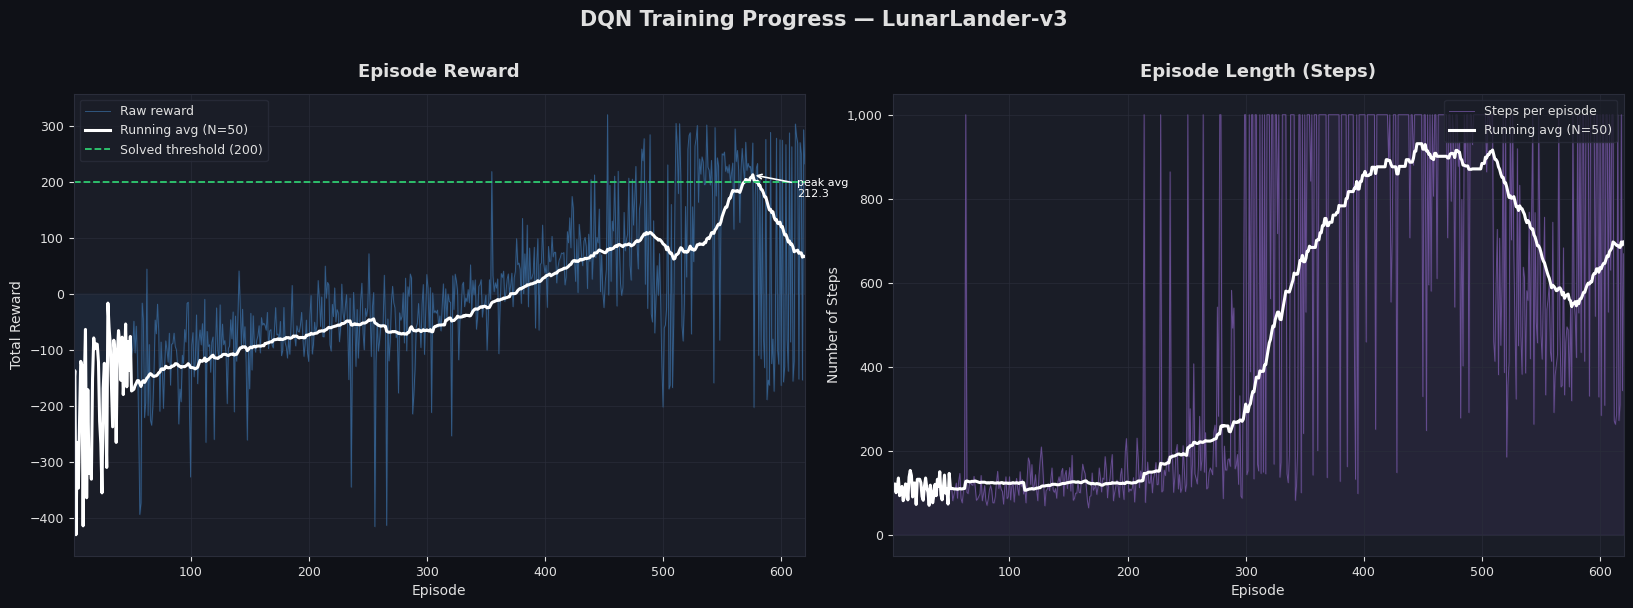

Saved → dqn_training.png


In [42]:
episodes = np.arange(1, N_episodes + 1)
reward_avg = running_average(episode_reward_list, n_ep_running_average)
steps_avg  = running_average(episode_number_of_steps, n_ep_running_average)

fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(20, 6),
    gridspec_kw={"wspace": 0.12}          # tighter horizontal gap between plots
)
fig.patch.set_facecolor("#0f1117")        # dark canvas

COLORS = {
    "raw_reward":  "#4c9be8",
    "avg_reward":  "#ffffff",
    "solved":      "#2ecc71",
    "raw_steps":   "#b07cf7",
    "avg_steps":   "#ffffff",
    "grid":        "#2a2d3a",
    "bg":          "#1a1d27",
    "text":        "#e0e0e0",
}

def style_ax(ax, title):
    ax.set_facecolor(COLORS["bg"])
    ax.set_title(title, color=COLORS["text"], fontsize=13, fontweight="bold", pad=12)
    ax.tick_params(colors=COLORS["text"], labelsize=9)
    ax.xaxis.label.set_color(COLORS["text"])
    ax.yaxis.label.set_color(COLORS["text"])
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS["grid"])
    ax.grid(color=COLORS["grid"], linewidth=0.6, alpha=0.8)
    ax.set_xlim(episodes[0], episodes[-1])

# ── Left: Reward ──────────────────────────────────────────────────────────────
ax = axes[0]
style_ax(ax, "Episode Reward")

ax.fill_between(episodes, episode_reward_list,
                alpha=0.08, color=COLORS["raw_reward"])
ax.plot(episodes, episode_reward_list,
        color=COLORS["raw_reward"], linewidth=0.7, alpha=0.45, label="Raw reward")
ax.plot(episodes, reward_avg,
        color=COLORS["avg_reward"], linewidth=2.2,
        label=f"Running avg (N={n_ep_running_average})")
ax.axhline(200, color=COLORS["solved"], linewidth=1.3,
           linestyle="--", label="Solved threshold (200)")

ax.set_xlabel("Episode", fontsize=10)
ax.set_ylabel("Total Reward", fontsize=10)
ax.legend(fontsize=9, facecolor="#1a1d27", edgecolor=COLORS["grid"],
          labelcolor=COLORS["text"], loc="upper left")

# annotate best running average
best_idx = int(np.argmax(reward_avg))
ax.annotate(
    f"peak avg\n{reward_avg[best_idx]:.1f}",
    xy=(episodes[best_idx], reward_avg[best_idx]),
    xytext=(episodes[best_idx] + N_episodes * 0.06, reward_avg[best_idx] - 40),
    color=COLORS["avg_reward"], fontsize=8,
    arrowprops=dict(arrowstyle="->", color=COLORS["avg_reward"], lw=1.2),
)

# ── Right: Steps ──────────────────────────────────────────────────────────────
ax = axes[1]
style_ax(ax, "Episode Length (Steps)")

ax.fill_between(episodes, episode_number_of_steps,
                alpha=0.08, color=COLORS["raw_steps"])
ax.plot(episodes, episode_number_of_steps,
        color=COLORS["raw_steps"], linewidth=0.7, alpha=0.45, label="Steps per episode")
ax.plot(episodes, steps_avg,
        color=COLORS["avg_steps"], linewidth=2.2,
        label=f"Running avg (N={n_ep_running_average})")

ax.set_xlabel("Episode", fontsize=10)
ax.set_ylabel("Number of Steps", fontsize=10)
ax.legend(fontsize=9, facecolor="#1a1d27", edgecolor=COLORS["grid"],
          labelcolor=COLORS["text"], loc="upper right")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Shared super-title ────────────────────────────────────────────────────────
fig.suptitle(
    "DQN Training Progress — LunarLander-v3",
    color=COLORS["text"], fontsize=15, fontweight="bold", y=1.02
)

plt.savefig("dqn_training.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → dqn_training.png")

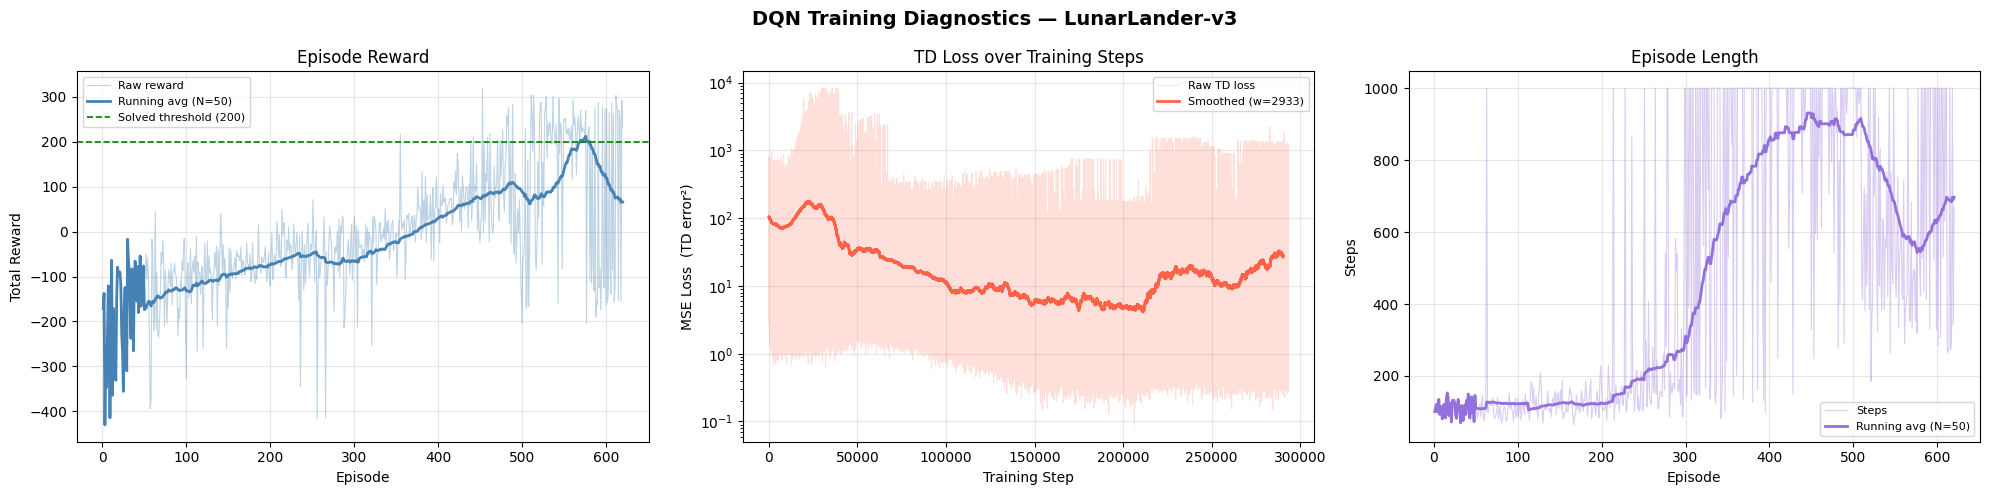

Saved → dqn_diagnostics.png


In [43]:


# --- helper already defined in your notebook ---
# running_average(x, N)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("DQN Training Diagnostics — LunarLander-v3", fontsize=14, fontweight='bold')

episodes = np.arange(1, N_episodes + 1)

# ── Plot 1: Episode Reward + Running Average ──────────────────────────────────
ax = axes[0]
ax.plot(episodes, episode_reward_list, alpha=0.35, color='steelblue', linewidth=0.8, label='Raw reward')
ax.plot(episodes, running_average(episode_reward_list, n_ep_running_average),
        color='steelblue', linewidth=2, label=f'Running avg (N={n_ep_running_average})')
ax.axhline(200, color='green', linestyle='--', linewidth=1.2, label='Solved threshold (200)')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Episode Reward')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Plot 2: TD Loss Curve ─────────────────────────────────────────────────────
ax = axes[1]
loss_arr = np.array(loss_history)
smooth_window = max(1, len(loss_arr) // 100)   # ~1% of total steps
loss_smooth = np.convolve(loss_arr, np.ones(smooth_window) / smooth_window, mode='valid')
steps_axis  = np.arange(len(loss_arr))
steps_smooth = np.arange(len(loss_smooth))

ax.plot(steps_axis,  loss_arr,    alpha=0.2, color='tomato', linewidth=0.6, label='Raw TD loss')
ax.plot(steps_smooth, loss_smooth, color='tomato', linewidth=2,   label=f'Smoothed (w={smooth_window})')
ax.set_xlabel('Training Step')
ax.set_ylabel('MSE Loss  (TD error²)')
ax.set_title('TD Loss over Training Steps')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_yscale('log')   # log-scale exposes early vs late loss magnitude clearly

# ── Plot 3: Steps per Episode + Running Average ───────────────────────────────
ax = axes[2]
ax.plot(episodes, episode_number_of_steps, alpha=0.35, color='mediumpurple', linewidth=0.8, label='Steps')
ax.plot(episodes, running_average(episode_number_of_steps, n_ep_running_average),
        color='mediumpurple', linewidth=2, label=f'Running avg (N={n_ep_running_average})')
ax.set_xlabel('Episode')
ax.set_ylabel('Steps')
ax.set_title('Episode Length')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dqn_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → dqn_diagnostics.png")

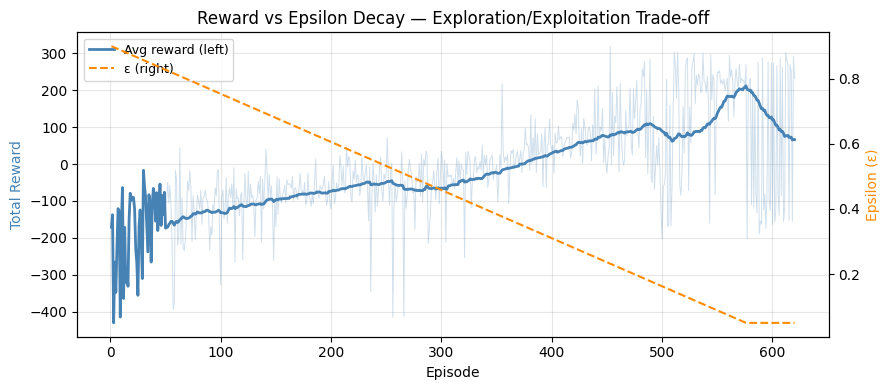

In [44]:
fig, ax = plt.subplots(figsize=(9, 4))

Z = int(0.93 * N_episodes)
eps_per_episode = [epsilon_decay(e, Z, eps_max=0.9, eps_min=0.05, method=method)
                   for e in range(1, N_episodes + 1)]

ax2 = ax.twinx()
ax.plot(episodes, episode_reward_list, alpha=0.25, color='steelblue', linewidth=0.7)
ax.plot(episodes, running_average(episode_reward_list, n_ep_running_average),
        color='steelblue', linewidth=2, label='Avg reward (left)')
ax2.plot(episodes, eps_per_episode, color='darkorange', linewidth=1.5,
         linestyle='--', label='ε (right)')

ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward', color='steelblue')
ax2.set_ylabel('Epsilon (ε)', color='darkorange')
ax.set_title('Reward vs Epsilon Decay — Exploration/Exploitation Trade-off')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("dqn_epsilon_overlay.png", dpi=150, bbox_inches='tight')
plt.show()

#### Visualize the Lundar Landing

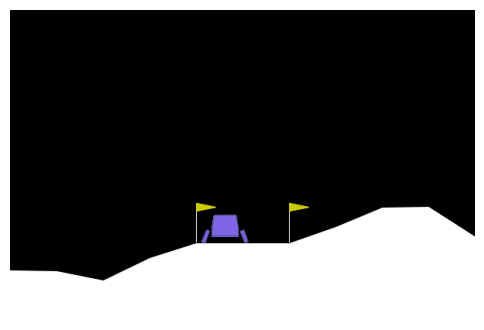

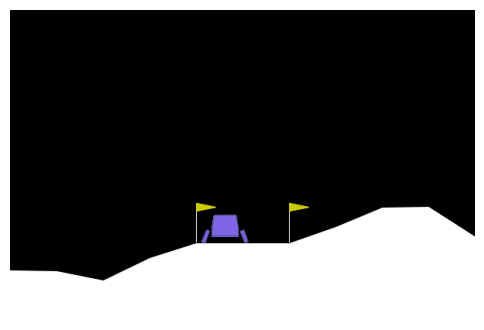

In [48]:
import os, time
import random
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

SEED=123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

assert os.path.exists("best_model.pth"), "best_model.pth not found in current working directory"

env_viz = gym.make("LunarLander-v3", render_mode="rgb_array")
env_viz.action_space.seed(SEED)
env_viz.observation_space.seed(SEED)
state, _ = env_viz.reset(seed=SEED)

model_viz = Agent(input_size=dim_state, output_size=n_actions, hidden_size=hidden_size)
model_viz.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
model_viz.eval()

fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(env_viz.render())
ax.axis("off")

done = False
while not done:
    with torch.no_grad():
        q_values = model_viz(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
        action = q_values.argmax(dim=1).item()

    state, reward, terminated, truncated, _ = env_viz.step(action)
    done = terminated or truncated

    img.set_data(env_viz.render())
    display(fig)
    clear_output(wait=True)
    # time.sleep(0.0004)

display(fig)  # keep last frame visible
env_viz.close()